# Einfluss der Rührgeschwindigkeit auf die Biomassebildung

Ein Biotechnologieunternehmen untersucht den Einfluss der Rührgeschwindigkeit auf die Biomassebildung in einem Fermentationsprozess.

Die Rührgeschwindigkeit beeinflusst die Durchmischung des Mediums sowie die Sauerstoffversorgung der Mikroorganismen. Ziel des Experiments ist es zu untersuchen, ob sich die mittlere Biomassekonzentration bei unterschiedlichen Rührgeschwindigkeiten unterscheidet.

## Versuchsaufbau

- Faktor: Rührgeschwindigkeit
- Faktorstufen: 100, 200, 300 und 400 rpm
- Antwortvariable: Biomassekonzentration [g/L]
- 5 unabhängige Fermentationen pro Faktorstufe
- Zufällige Versuchsdurchführung

## Fragestellung

Beeinflusst die Rührgeschwindigkeit die mittlere Biomassekonzentration?

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [2]:
df = pd.DataFrame({
    "rpm": [
        100,100,100,100,100,
        200,200,200,200,200,
        300,300,300,300,300,
        400,400,400,400,400
    ],
    "Biomass": [
        6.8,7.2,7.0,6.9,7.1,
        8.0,8.4,8.2,8.1,8.3,
        10.2,9.9,10.5,10.1,10.3,
        9.2,9.5,9.3,9.1,9.4
    ]
})

df

,rpm,Biomass
0,100,6.8
1,100,7.2
2,100,7.0
3,100,6.9
4,100,7.1
5,200,8.0
6,200,8.4
7,200,8.2
8,200,8.1
9,200,8.3


# Grafische Analyse

Vor der eigentlichen statistischen Analyse sollten die Daten grafisch untersucht werden.

Der folgende Boxplot ermöglicht einen Vergleich der Verteilungen, Mittelwerte und Streuungen der Biomassekonzentration für die verschiedenen Rührgeschwindigkeiten.

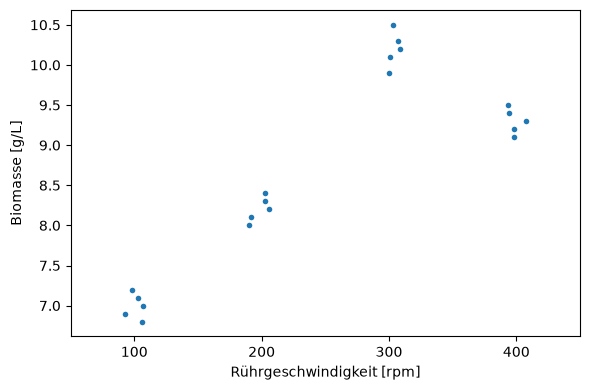

In [3]:
plt.figure(figsize=(6,4))

sns.stripplot(
    data=df,
    x="rpm",
    y="Biomass",
    size=4
)

plt.xlabel("Rührgeschwindigkeit [rpm]")
plt.ylabel("Biomasse [g/L]")

plt.tight_layout()

plt.show()

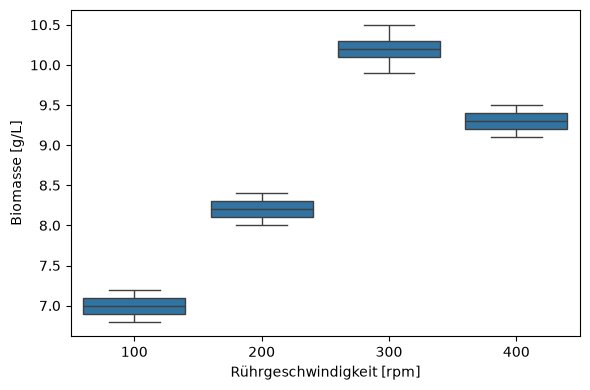

In [4]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="rpm",
    y="Biomass"
)

plt.xlabel("Rührgeschwindigkeit [rpm]")
plt.ylabel("Biomasse [g/L]")

plt.tight_layout()

plt.show()

In [5]:
df.groupby("rpm")["Biomass"].agg(
    ["count","mean","std","var"]
)

,count,mean,std,var
rpm,,,,
100,5,7.0,0.158114,0.025
200,5,8.2,0.158114,0.025
300,5,10.2,0.223607,0.050
400,5,9.3,0.158114,0.025


# Varianzanalyse (ANOVA)

Zur Untersuchung des Einflusses der Rührgeschwindigkeit wird eine einfaktorielle ANOVA durchgeführt.

Die Hypothesen lauten:

$H_0:\mu_{100}=\mu_{200}=\mu_{300}=\mu_{400}$

$H_1:\text{Mindestens ein Mittelwert unterscheidet sich.}$

Ein großer Wert der F-Teststatistik spricht gegen die Nullhypothese und deutet auf Unterschiede zwischen den Mittelwerten hin.

In [6]:
df.groupby("rpm")["Biomass"].mean()

rpm
100     7.0
200     8.2
300    10.2
400     9.3
Name: Biomass, dtype: float64

In [7]:
grand_mean = df["Biomass"].mean()

grand_mean

np.float64(8.675)

In [8]:
means = df.groupby("rpm")["Biomass"].mean()

n = 5

ss_treatments = n * (
    (means - grand_mean)**2
).sum()

ss_treatments

np.float64(28.737499999999994)

In [9]:
ss_error = (
    df.groupby("rpm")
      .apply(
          lambda x:
          ((x["Biomass"]-x["Biomass"].mean())**2).sum()
      )
      .sum()
)

ss_error

np.float64(0.5000000000000007)

In [10]:
ss_total = ss_treatments + ss_error

ss_total

np.float64(29.237499999999994)

In [11]:
model = ols(
    "Biomass ~ (rpm)",
    data=df
).fit()

anova_lm(
    model,
    typ=2
)

,sum_sq,df,F,PR(>F)
rpm,19.8025,1.0,37.779014,0.000008
Residual,9.4350,18.0,NaN,NaN


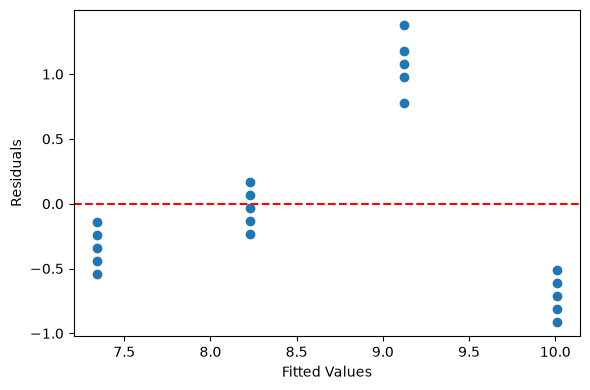

In [12]:
plt.figure(figsize=(6,4))

plt.scatter(
    model.fittedvalues,
    model.resid
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import t
import numpy as np

alpha = 0.05

MSE = 0.03125
n = 5
df_error = 16

tcrit = t.ppf(1 - alpha/2, df_error)

print("Fisher Least Significant Difference (LSD)")
print("-" * 50)

print(f"Signifikanzniveau α = {alpha}")
print(f"Fehlerfreiheitsgrade = {df_error}")
print(f"t-Kritisch = {tcrit:.3f}")
print(f"MSE = {MSE:.5f}")
print(f"n = {n}")


LSD = tcrit * np.sqrt(2*MSE/n)
print(f"\nLSD = {LSD:.3f}")

Fisher Least Significant Difference (LSD)
--------------------------------------------------
Signifikanzniveau α = 0.05
Fehlerfreiheitsgrade = 16
t-Kritisch = 2.120
MSE = 0.03125
n = 5

LSD = 0.237


In [14]:
from itertools import combinations

means = df.groupby("rpm")["Biomass"].mean()

print("\nVergleich der Mittelwerte")
print("-" * 50)

for a, b in combinations(means.index, 2):

    diff = abs(means[a] - means[b])

    print(
        f"{a} rpm vs {b} rpm:"
        f"  |Δ| = {diff:.3f}"
        f"  {'>' if diff > LSD else '<='}"
        f"  {LSD:.3f}"
    )


Vergleich der Mittelwerte
--------------------------------------------------
100 rpm vs 200 rpm:  |Δ| = 1.200  >  0.237
100 rpm vs 300 rpm:  |Δ| = 3.200  >  0.237
100 rpm vs 400 rpm:  |Δ| = 2.300  >  0.237
200 rpm vs 300 rpm:  |Δ| = 2.000  >  0.237
200 rpm vs 400 rpm:  |Δ| = 1.100  >  0.237
300 rpm vs 400 rpm:  |Δ| = 0.900  >  0.237


In [15]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

result = pairwise_tukeyhsd(
    df["Biomass"],
    df["rpm"]
)

print(result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
   100    200      1.2   0.0  0.8801  1.5199   True
   100    300      3.2   0.0  2.8801  3.5199   True
   100    400      2.3   0.0  1.9801  2.6199   True
   200    300      2.0   0.0  1.6801  2.3199   True
   200    400      1.1   0.0  0.7801  1.4199   True
   300    400     -0.9   0.0 -1.2199 -0.5801   True
---------------------------------------------------


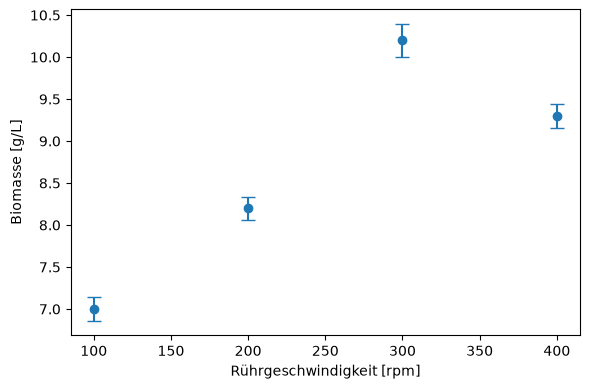

In [16]:
means = df.groupby("rpm")["Biomass"].mean()
std = df.groupby("rpm")["Biomass"].std()

ci = 1.96 * std / np.sqrt(5)

plt.figure(figsize=(6,4))

plt.errorbar(
    means.index,
    means,
    yerr=ci,
    fmt="o",
    capsize=5
)

plt.xlabel("Rührgeschwindigkeit [rpm]")
plt.ylabel("Biomasse [g/L]")

plt.tight_layout()
plt.show()

# Regression als ergänzende Darstellung

Die Rührgeschwindigkeit ist eine kontinuierliche Einflussgröße.

Daher kann zusätzlich ein Regressionsmodell angepasst werden. Die ANOVA untersucht, ob sich die Mittelwerte unterscheiden, während die Regression den funktionalen Zusammenhang zwischen Rührgeschwindigkeit und Biomassebildung beschreibt.

Die folgende Grafik zeigt eine quadratische Regressionskurve durch die Gruppenmittelwerte.

Ein solcher Zusammenhang deutet darauf hin, dass eine optimale Rührgeschwindigkeit existieren könnte.

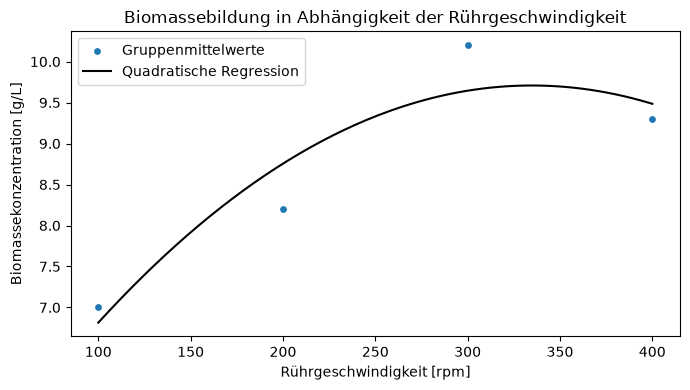

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Mittelwerte je Faktorstufe
means = (
    df.groupby("rpm")["Biomass"]
      .mean()
)

x = means.index.values
y = means.values

# Quadratische Regression
coef = np.polyfit(x, y, deg=2)

x_fit = np.linspace(100, 400, 200)

y_fit = np.polyval(coef, x_fit)

plt.figure(figsize=(7,4))

plt.scatter(
    x,
    y,
    s=15,
    label="Gruppenmittelwerte"
)

plt.plot(
    x_fit,
    y_fit,
    color="black",
    label="Quadratische Regression"
)

plt.xlabel("Rührgeschwindigkeit [rpm]")
plt.ylabel("Biomassekonzentration [g/L]")
plt.title("Biomassebildung in Abhängigkeit der Rührgeschwindigkeit")

plt.legend()

plt.tight_layout()
plt.show()


# Interpretation

Die ANOVA zeigt einen signifikanten Einfluss der Rührgeschwindigkeit auf die Biomassekonzentration.

Die mittlere Biomasse steigt zunächst mit zunehmender Rührgeschwindigkeit an, erreicht bei etwa 300 rpm ein Maximum und nimmt anschließend wieder leicht ab.

Die Regressionskurve bestätigt diesen Trend und deutet auf einen optimalen Betriebsbereich hin.